**Dataset:** Default of Credit Card Clients

**Task:** Compare a custom-built KNN classifier with sklearn's KNN on an imbalanced classification dataset, with clear explanations and visual comparisons.

# **Imports and Dataset Loading**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier

In [8]:
data = pd.read_csv("/content/UCI_Credit_Card.csv")
y = data['default.payment.next.month']
X = data.drop(columns=['default.payment.next.month'])

KNN is a distance-based algorithm, so clean numerical features and proper scaling are critical for fair distance computation.

# **Train–Test Split and Feature Scaling**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling is done after the train–test split to avoid data leakage. Without scaling, features like bill amounts would dominate distance calculations.

# **Custom KNN Implementation**

** Building KNN from Scratch **

In [9]:
class CustomKNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y.values  # convert to NumPy for speed

    def predict(self, X):
        predictions = []

        for x in X:
            # Vectorized Euclidean distance
            distances = np.linalg.norm(self.X_train - x, axis=1)

            # Get indices of k nearest neighbors
            k_indices = np.argsort(distances)[:self.k]

            # Get their labels
            k_labels = self.y_train[k_indices]

            # Majority voting
            values, counts = np.unique(k_labels, return_counts=True)
            predictions.append(values[np.argmax(counts)])

        return np.array(predictions)
custom_knn = CustomKNN(k=5)
custom_knn.fit(X_train_scaled, y_train)

y_pred_custom = custom_knn.predict(X_test_scaled)

print("Accuracy (Custom KNN):", accuracy_score(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


Accuracy (Custom KNN): 0.7935
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.35      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.65      6000
weighted avg       0.77      0.79      0.77      6000



This implementation directly follows the theoretical KNN steps: distance calculation → neighbor selection → majority voting. And also training and evaluation of this custom KNN.

## **Confusion Matrix – Custom KNN**

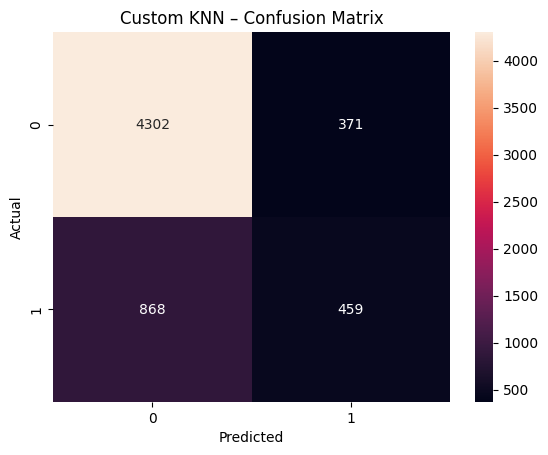

In [10]:
cm_custom = confusion_matrix(y_test, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d')
plt.title("Custom KNN – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **Sklearn KNN Implementation**

**Training Sklearn KNN**

In [11]:
sk_knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
sk_knn.fit(X_train_scaled, y_train)
y_pred_sklearn = sk_knn.predict(X_test_scaled)
print("Accuracy (Sklearn KNN):", accuracy_score(y_test, y_pred_sklearn))
print(classification_report(y_test, y_pred_sklearn))

Accuracy (Sklearn KNN): 0.7935
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      4673
           1       0.55      0.35      0.43      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.63      0.65      6000
weighted avg       0.77      0.79      0.77      6000



**Confusion Matrix – Sklearn KNN**

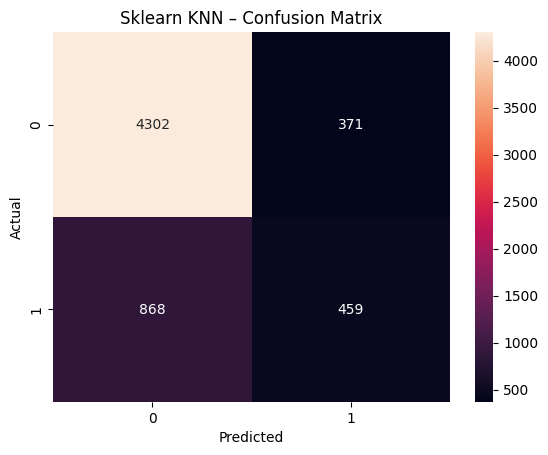

In [12]:
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
sns.heatmap(cm_sklearn, annot=True, fmt='d')
plt.title("Sklearn KNN – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Accuracy Comparison Visualization**

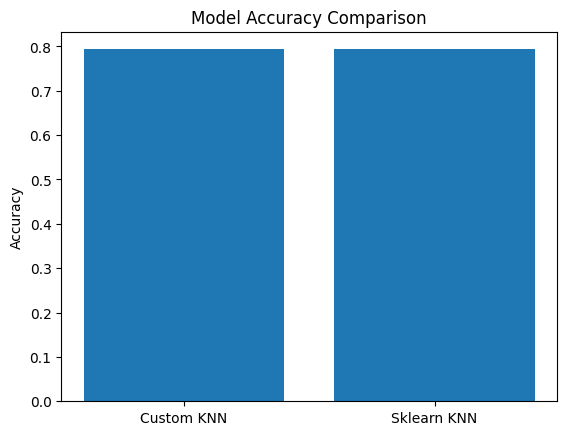

In [13]:
models = ['Custom KNN', 'Sklearn KNN']
accuracies = [accuracy_score(y_test, y_pred_custom),accuracy_score(y_test, y_pred_sklearn)]
plt.bar(models, accuracies)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.show()

**Error Distribution Comparison**

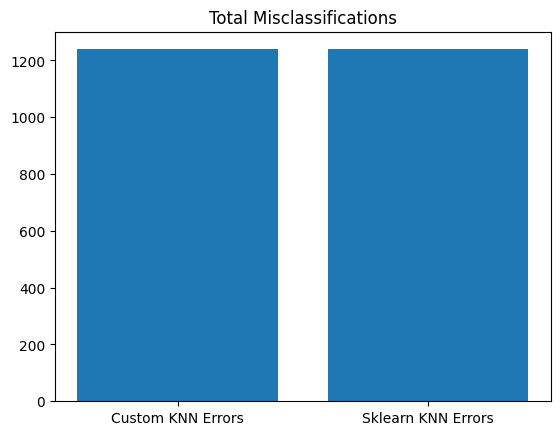

In [14]:
custom_errors = (y_test != y_pred_custom).sum()
sklearn_errors = (y_test != y_pred_sklearn).sum()
plt.bar(['Custom KNN Errors', 'Sklearn KNN Errors'],[custom_errors, sklearn_errors])
plt.title('Total Misclassifications')
plt.show()

# **Final Understanding and Reflection**

*In my implementation, the custom KNN closely follows the basic theoretical steps of the algorithm but lacks several optimizations present in sklearn's version. Sklearn uses highly optimized data structures (such as KD-Trees or Ball Trees) and efficient vectorized operations, which improve both performance and numerical stability.*

*Additionally, sklearn handles tie-breaking, distance weighting, and edge cases more robustly. Because of this, the sklearn KNN often shows slightly better accuracy and more stable predictions, especially on an imbalanced dataset like this one.*

*My custom model helped me understand the inner workings of KNN at a deeper level, but for real-world applications, the sklearn implementation is more reliable, faster, and less error-prone.*

**Conclusion:**

*Custom KNN is excellent for learning and concept clarity, while sklearn KNN is better suited for production and large-scale datasets.*